# **Titanic - ML (Logistic Regression vs KNN):**
* **[EDA](#intLink0)**
* **[Feature Engineering](#intLink1)** 
* **[Logistic Reggresion](#intLink2)**
* **[k-nearest neighbors(KNN)](#intLink3)**
* **[Elbow Method for Choosing Reasonable K Values)](#intLink4)**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
#loading the data
train_set = pd.read_csv("../input/titanic/train.csv")
test_set = pd.read_csv("../input/titanic/test.csv")

In [4]:
train_set.head(890)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


# <div id="intLink0">EDA</div>

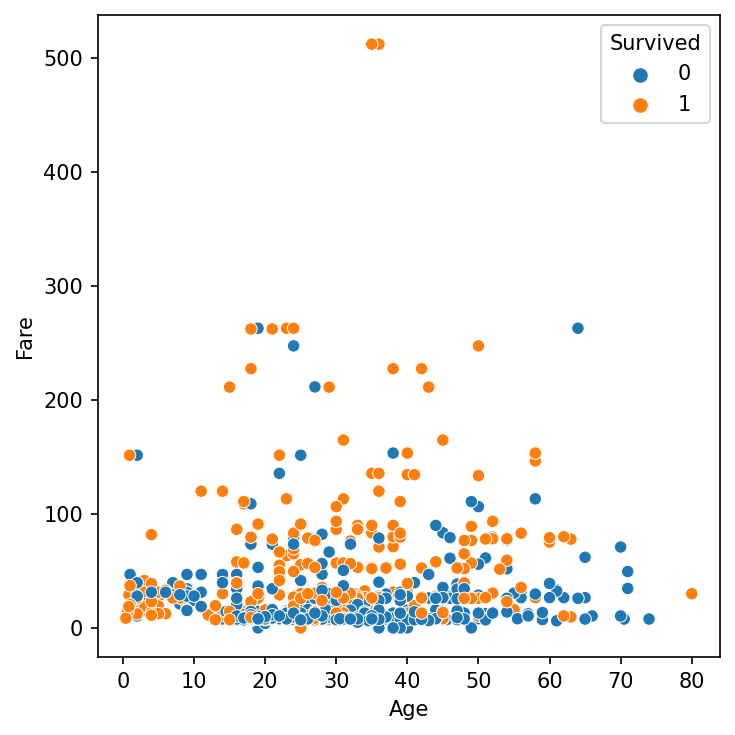

In [5]:
plt.figure(figsize=(5, 5), dpi=150)
sns.scatterplot(data=train_set, x='Age', y='Fare', hue='Survived')
plt.tight_layout()
plt.show()

* as you can see we have Outliner: pepole who paid more that 450$ survived !!! so we drop the them

In [9]:
#Remove the outliers:
index_drop=train_set[train_set['Fare']>450].index
train_set=train_set.drop(index_drop, axis=0)

<AxesSubplot:xlabel='Age', ylabel='Fare'>

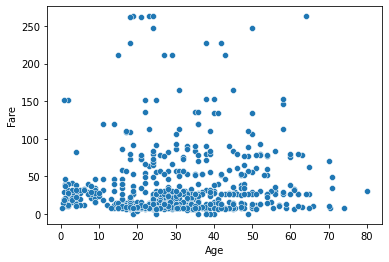

In [10]:

sns.scatterplot(x='Age', y='Fare', data=train_set)
#plt.axhline(y=450, color='r')
#plt.axvline(x=28, color='r')

In [11]:
quantitative_col = [ 'Pclass', 'Age','Fare','SibSp','Parch']

In [12]:
survived_people = train_set[train_set.Survived == 1]
unsurvived_people = train_set[train_set.Survived == 0]

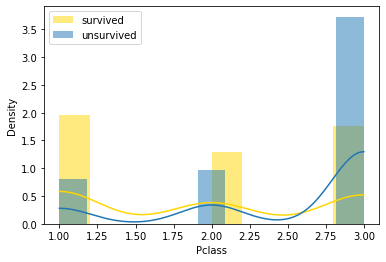

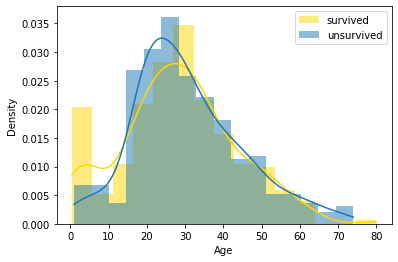

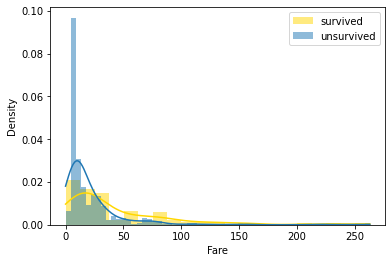

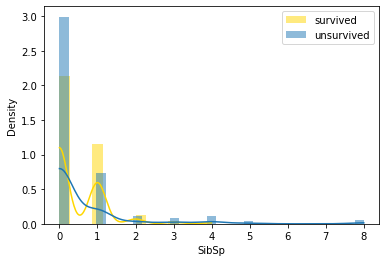

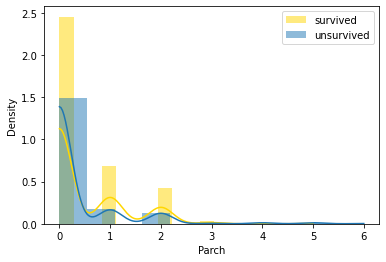

In [15]:
for col in quantitative_col :
    plt.figure()
    sns.histplot(survived_people[col], label='survived',kde=True,color="gold", stat="density", linewidth=0
)
    sns.histplot(unsurvived_people[col], label='unsurvived',kde=True, stat="density", linewidth=0
)
    plt.legend()

 # <div id="intLink1"> Feature Engineering 
 * Handling missing values and useless features
 * Handling catagorical values and replacing them with Numbers </div>

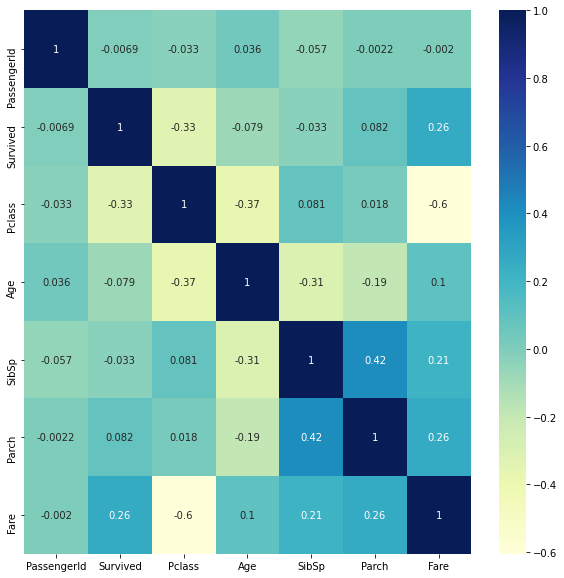

In [16]:
# get correlations of each features in dataset
# Plotting Heat Map to visualise correlation data better. 
# Drwan for only features having high correlation 
# (>0.0) with Target Variable
corr = train_set.corr()
top_corr_features = corr.index[abs(corr["Survived"])>0.0]

plt.figure(figsize=(10,10))
#plot heat map
g=sns.heatmap(train_set[top_corr_features].corr(),annot=True,cmap="YlGnBu")

* Survived - that's the target, 0 means the passenger did not survive, while 1 means he/she survived.
* Pclass - passenger class.
* Name -**-----> Drop (they don't push you in the ocean acording to your ticketId, I hope ;)**
* Sex
* Age **-----> filling the missing values acording to mean of each gender**
* SibSp - how many siblings & spouses of the passenger aboard the Titanic.
* Parch - how many children & parents of the passenger aboard the Titanic.
* Ticket - ticket id **-----> Drop**
* Fare - the price paid (in pounds)
* Cabin - passenger's cabin number **-----> Drop (just drop the Cabin, no one was at their Cabins they all were at the ballroom, LOL) too many missing values**
* Embarked - where the passenger embarked the Titanic

* passengerId has negetive correlaton so we drop that because Id is an unnecesery feature
* we also drop more unnececeary fetures like Name and Ticket

In [17]:
train_set= train_set.drop(['PassengerId'],axis=1)

In [18]:
train_set= train_set.drop(['Name'],axis=1)

In [19]:
train_set= train_set.drop(['Ticket'],axis=1)

* Missing Values

In [20]:
def missing_percent(train_set):
    nan_percent = 100*(train_set.isnull().sum()/len(train_set))
    nan_percent = nan_percent[nan_percent>0].sort_values(ascending=False).round(1)
    DataFrame = pd.DataFrame(nan_percent)
    # Rename the columns
    mis_percent_table = DataFrame.rename(columns = {0 : '% of Misiing Values'}) 
    # Sort the table by percentage of missing descending
    mis_percent = mis_percent_table
    return mis_percent

In [21]:
train_set.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       686
Embarked      2
dtype: int64

In [23]:
miss = missing_percent(train_set)
miss

,% of Misiing Values
Cabin,77.3
Age,19.9
Embarked,0.2


* fill NAN valueS in the Age columns with the mean value according to the Gender

In [24]:
train_set['Age'] = train_set['Age'].fillna(train_set.groupby('Sex')['Age'].transform('mean'))

In [25]:
#check Embarked missing value
train_set[train_set['Embarked'].isnull()]

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
61,1,1,female,38.0,0,0,80.0,B28,NaN
829,1,1,female,62.0,0,0,80.0,B28,NaN


In [26]:
# we fill the missing value with S = southampton because this city has the most population amongst others it is not accurate but we try our luck 
train_set["Embarked"]= train_set["Embarked"].fillna("S")

In [27]:
train_set= train_set.drop(['Cabin'],axis=1)

In [28]:
miss = missing_percent(train_set)
miss

,% of Misiing Values


No missing value...

* Handling catagorical values

In [29]:
train_set['Sex'] = train_set['Sex'].replace(['female'],'1')
train_set['Sex'] = train_set['Sex'].replace(['male'],'0')

In [30]:
train_set['Embarked'] = train_set['Embarked'].replace(['S'],'0')
train_set['Embarked'] = train_set['Embarked'].replace(['Q'],'1')
train_set['Embarked'] = train_set['Embarked'].replace(['C'],'2')

# <div id="intLink2"> Logistic Regression </div>


In [31]:
X= train_set.drop('Survived', axis=1)
y= train_set['Survived']

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

* first we should scale our Features

In [34]:
from sklearn.preprocessing import StandardScaler

In [35]:
scaler= StandardScaler()

In [36]:
scaler.fit(X_train)

StandardScaler()

In [37]:
scaled_X_train= scaler.transform(X_train)
scaled_X_test= scaler.transform(X_test)

In [44]:
# now we train our model
from sklearn.linear_model import LogisticRegression
log_model= LogisticRegression()

In [45]:
log_model.fit(scaled_X_train, y_train)

LogisticRegression()

In [46]:
y_pred= log_model.predict(scaled_X_test)

In [47]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, plot_confusion_matrix

In [48]:
accuracy_score(y_test, y_pred)

0.8202247191011236

# we get 0.82 accuracies with simple Logistic Regression

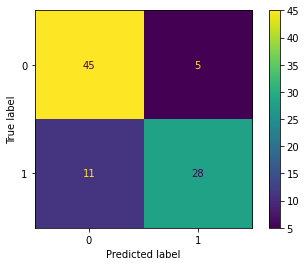

In [49]:
plot_confusion_matrix(log_model, scaled_X_test, y_test)

* True Positive: 45
* True Negetive: 11
* False Positive: 5
* False Negetive: 28


# <div id="intLink3"> K-nearest neighbors </div>

In [50]:
#we already split the data and we scaled it so we just need to train the model
from sklearn.neighbors import KNeighborsClassifier
knn_model= KNeighborsClassifier(n_neighbors=1)

In [51]:
knn_model.fit(scaled_X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

In [52]:
y_pred= knn_model.predict(scaled_X_test)

In [53]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
accuracy_score(y_test, y_pred)

0.7640449438202247

# we get 0.76 accuracy using KNN with **1** neighbor 

In [54]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.86      0.80        50
           1       0.78      0.64      0.70        39

    accuracy                           0.76        89
   macro avg       0.77      0.75      0.75        89
weighted avg       0.77      0.76      0.76        89



# <div id="intLink4"> Elbow Method for Choosing Reasonable K Values </div>

In [55]:
test_error_rate= []


for k in range (1, 30):
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(scaled_X_train, y_train)
    
    y_pred_test = knn_model.predict(scaled_X_test)
    
    test_error=1- accuracy_score(y_test, y_pred_test)
    test_error_rate.append(test_error)

Text(0.5, 0, 'K Value')

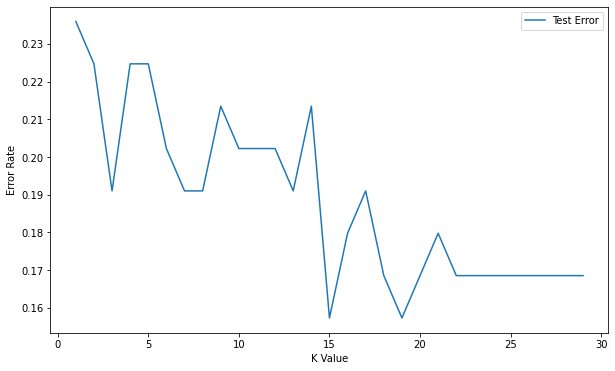

In [56]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 30), test_error_rate, label='Test Error')
plt.legend()
plt.ylabel('Error Rate')
plt.xlabel('K Value')

acording to the plot we choose K=15 cause it has a significantly lower Error rate

we train the model with 15 neighbors

In [58]:
from sklearn.neighbors import KNeighborsClassifier
knn_model= KNeighborsClassifier(n_neighbors=15)

In [59]:
knn_model.fit(scaled_X_train, y_train)

KNeighborsClassifier(n_neighbors=15)

In [60]:
y_pred= knn_model.predict(scaled_X_test)

In [61]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
accuracy_score(y_test, y_pred)

0.8426966292134831

# accuracy is 0.84 with 15 n neighbors, the performance improved

In [62]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.92      0.87        50
           1       0.88      0.74      0.81        39

    accuracy                           0.84        89
   macro avg       0.85      0.83      0.84        89
weighted avg       0.85      0.84      0.84        89



I am going to update the Notebook